In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

In [ ]:
#1. First 5 and last 5 records
print(df.head())
print(df.tail())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [ ]:
#2. Number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

if df.shape[0] > df.shape[1]:
    print("Dataset has more observations than features")
else:
    print("Dataset has more features than observations")

Rows: 891
Columns: 12
Dataset has more observations than features


In [ ]:
#3. Column names, data types and non-null values

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:
#4. Statistical summary

print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [ ]:
#5. Numerical and categorical columns
numerical = df.select_dtypes(include='number').columns
categorical = df.select_dtypes(include='object').columns

print("Numerical columns:")
print(numerical)

print("\nCategorical columns:")
print(categorical)

Numerical columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Categorical columns:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


In [ ]:
#6. Missing values in descending order

missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64


In [ ]:
#7. Percentage of missing values + columns >10%

missing_percent = df.isnull().mean() * 100

print(missing_percent.sort_values(ascending=False))

print("\nColumns having more than 10% missing data:")
print(missing_percent[missing_percent > 10])

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

Columns having more than 10% missing data:
Age      19.865320
Cabin    77.104377
dtype: float64


In [ ]:
#8. Number of unique values in categorical columns

for col in categorical:
    print(col, ":", df[col].nunique())

Name : 891
Sex : 2
Ticket : 681
Cabin : 147
Embarked : 3


In [ ]:
#9. Frequency of one categorical column
print(df['Sex'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


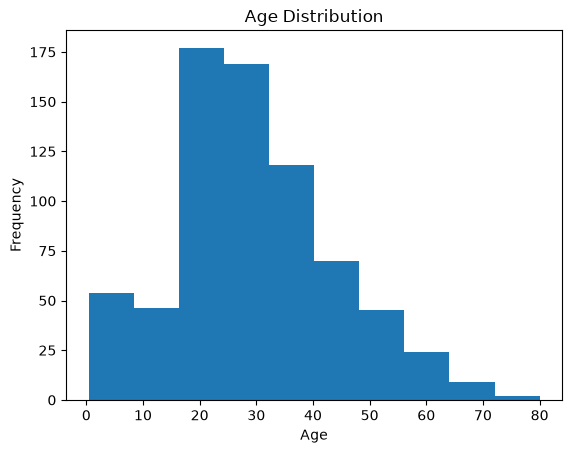

In [ ]:
#10. Histogram of numerical column



plt.hist(df['Age'].dropna())
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show() 

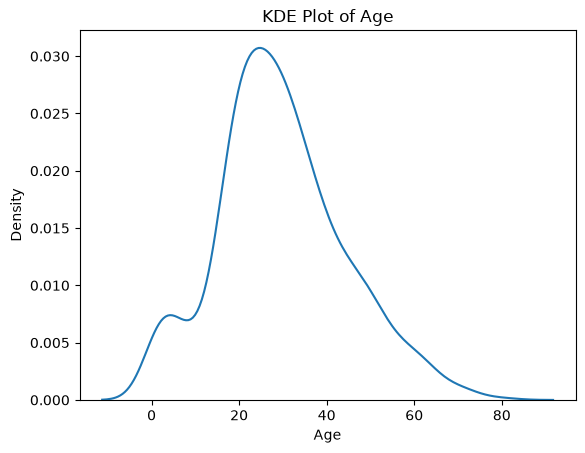

In [ ]:
#11. KDE plot
sns.kdeplot(df['Age'].dropna())
plt.xlabel("Age")
plt.title("KDE Plot of Age")
plt.show()

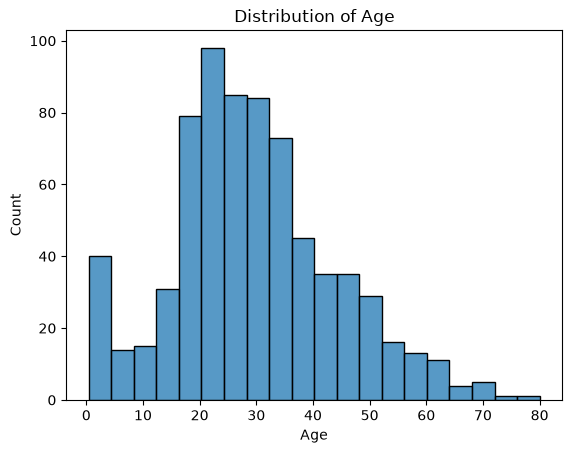

In [ ]:
#12. Distribution plot

sns.histplot(df['Age'].dropna())
plt.title("Distribution of Age")
plt.show()

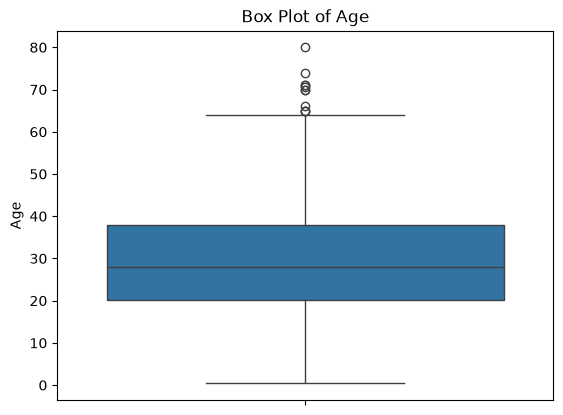

In [ ]:
#13. Box plot and outliers

sns.boxplot(y=df['Age'])
plt.title("Box Plot of Age")
plt.show()

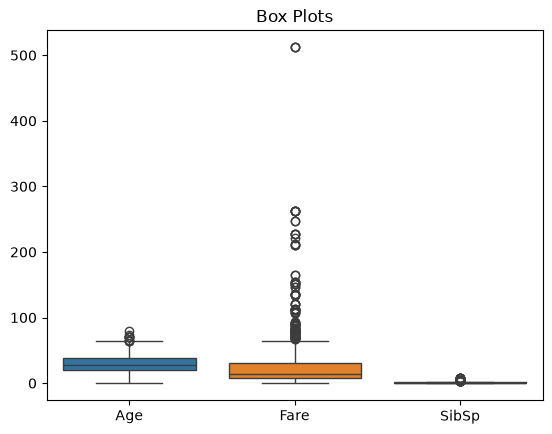

In [ ]:
#14. Box plots for three numerical columns

sns.boxplot(data=df[['Age', 'Fare', 'SibSp']])
plt.title("Box Plots")
plt.show()

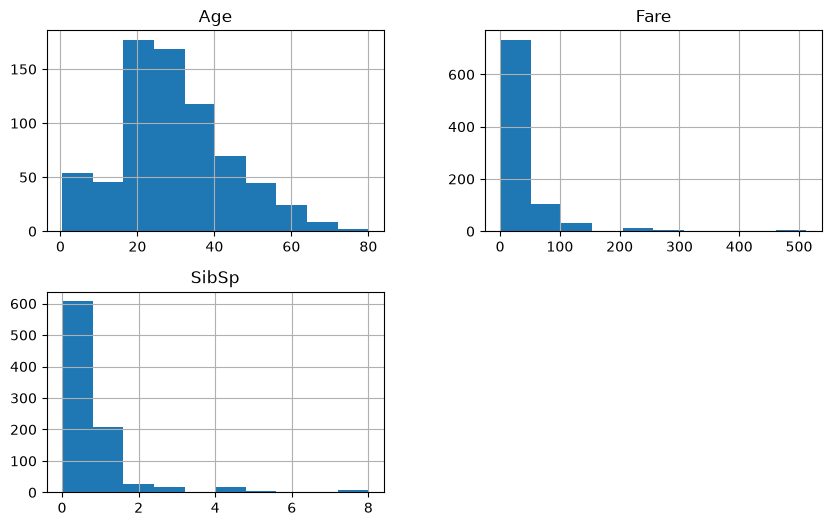

In [ ]:
#15. Histograms for three numerical features

df[['Age', 'Fare', 'SibSp']].hist(figsize=(10, 6))
plt.show()

In [ ]:
#16. Mean, median, min, max, standard deviation

x = df['Age'].dropna()

print("Mean:", x.mean())
print("Median:", x.median())
print("Minimum:", x.min())
print("Maximum:", x.max())
print("Standard Deviation:", x.std())

Mean: 29.69911764705882
Median: 28.0
Minimum: 0.42
Maximum: 80.0
Standard Deviation: 14.526497332334042


In [ ]:
#17. Numerical feature with highest standard deviation
std = df[numerical].std()

print(std)
print("\nHighest standard deviation:")
print(std.idxmax(), "=", std.max())

PassengerId    257.353842
Survived         0.486592
Pclass           0.836071
Age             14.526497
SibSp            1.102743
Parch            0.806057
Fare            49.693429
dtype: float64

Highest standard deviation:
PassengerId = 257.3538420152301


In [ ]:
#18. Numerical feature with largest range
ranges = df[numerical].max() - df[numerical].min()

print(ranges)
print("\nLargest range:")
print(ranges.idxmax(), "=", ranges.max())

PassengerId    890.0000
Survived         1.0000
Pclass           2.0000
Age             79.5800
SibSp            8.0000
Parch            6.0000
Fare           512.3292
dtype: float64

Largest range:
PassengerId = 890.0


In [ ]:
#19. Percentage of observations below mean

x = df['Age'].dropna()

percentage = (x < x.mean()).mean() * 100

print("Percentage below mean:", percentage, "%")

Percentage below mean: 53.78151260504202 %


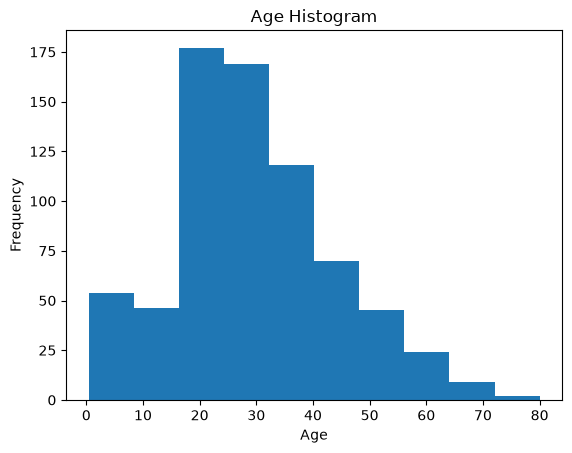

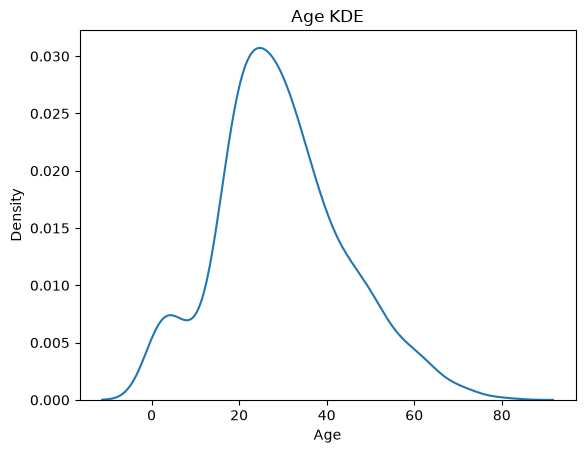

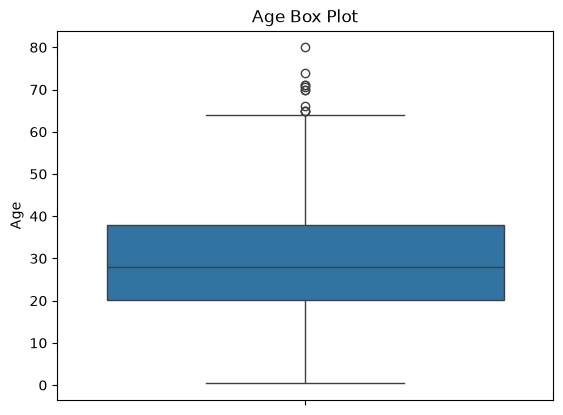

Mean: 29.69911764705882
Median: 28.0
Minimum: 0.42
Maximum: 80.0


'observations\n\nThe average age is around 30 years.\nThe median age is close to the mean.\nThe distribution is slightly right-skewed.\nSome older passengers appear as potential outliers.'

In [ ]:
#20. Complete Univariate Analysis

#Let's take Age.

#Histogram
plt.hist(df['Age'].dropna())
plt.title("Age Histogram")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#KDE
sns.kdeplot(df['Age'].dropna())
plt.title("Age KDE")
plt.show()

#Box plot
sns.boxplot(y=df['Age'])
plt.title("Age Box Plot")
plt.show()

#Statistics
x = df['Age'].dropna()

print("Mean:", x.mean())
print("Median:", x.median())
print("Minimum:", x.min())
print("Maximum:", x.max())

'''observations

The average age is around 30 years.
The median age is close to the mean.
The distribution is slightly right-skewed.
Some older passengers appear as potential outliers.'''

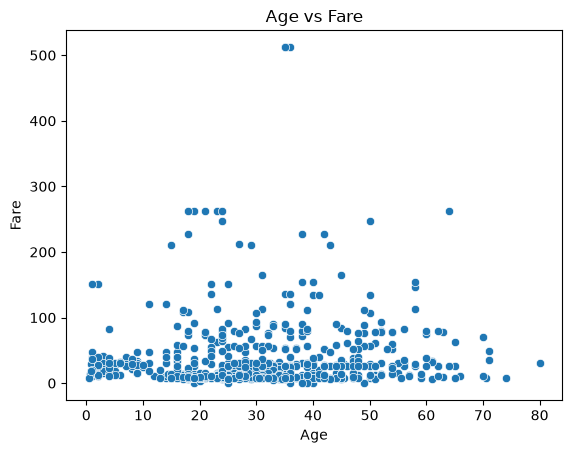

In [ ]:
#21. Scatter plot between two numerical columns

sns.scatterplot(data=df, x='Age', y='Fare')
plt.title("Age vs Fare")
plt.show()

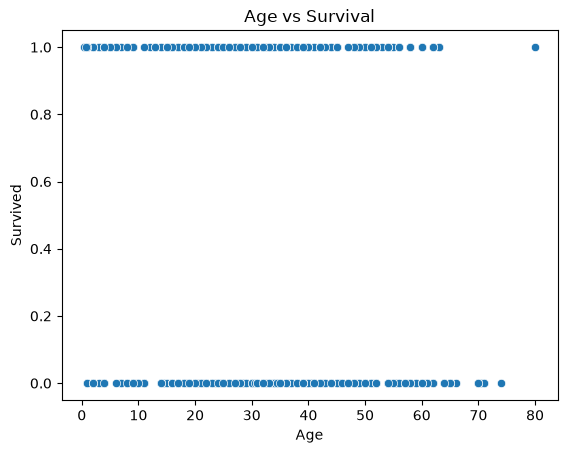

'Observation:\nThere is no strong relationship between individual age and survival because survival is a binary variable (0 or 1).'

In [ ]:
#22. Numerical feature vs target variable

#Target = Survived

sns.scatterplot(data=df, x='Age', y='Survived')
plt.title("Age vs Survival")
plt.show()

'''Observation:
There is no strong relationship between individual age and survival because survival is a binary variable (0 or 1).'''

Correlation: 0.09606669176903894


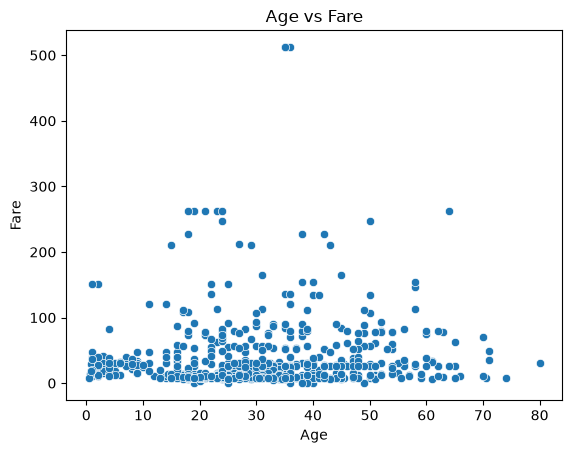

'Interpretation:\n\nCorrelation close to +1 → strong positive\nCorrelation close to -1 → strong negative\nCorrelation close to 0 → weak/no linear relationship'

In [ ]:
#23. Correlation coefficient + scatter plot
correlation = df['Age'].corr(df['Fare'])

print("Correlation:", correlation)

sns.scatterplot(data=df, x='Age', y='Fare')
plt.title("Age vs Fare")
plt.show()

'''Interpretation:

Correlation close to +1 → strong positive
Correlation close to -1 → strong negative
Correlation close to 0 → weak/no linear relationship'''

In [ ]:
#24. Correlation matrix
correlation_matrix = df[numerical].corr()

print(correlation_matrix)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


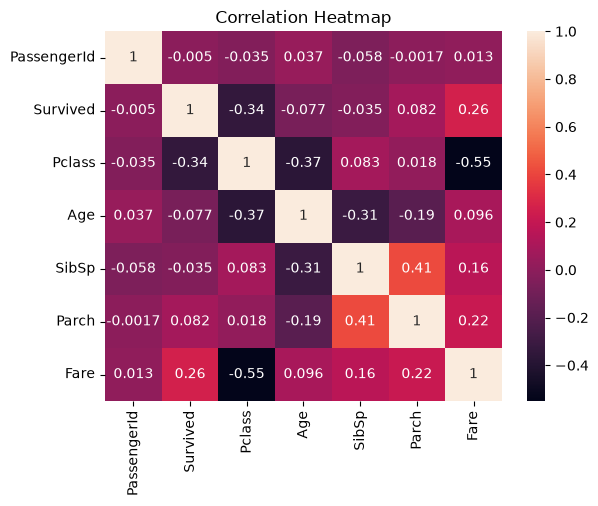

In [ ]:
#25. Correlation heatmap

sns.heatmap(df[numerical].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

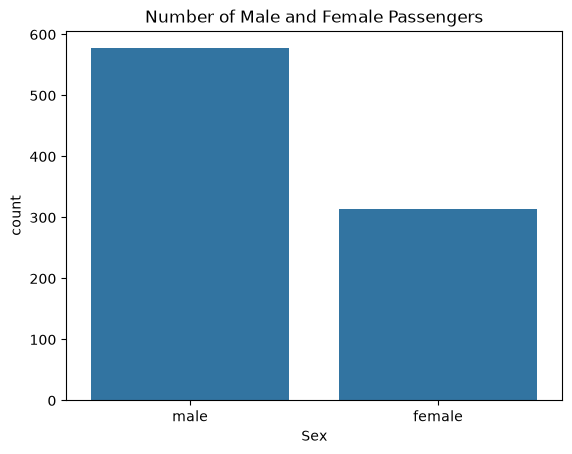

In [ ]:
#26. Count plot for categorical feature


sns.countplot(data=df, x='Sex')
plt.title("Number of Male and Female Passengers")
plt.show()

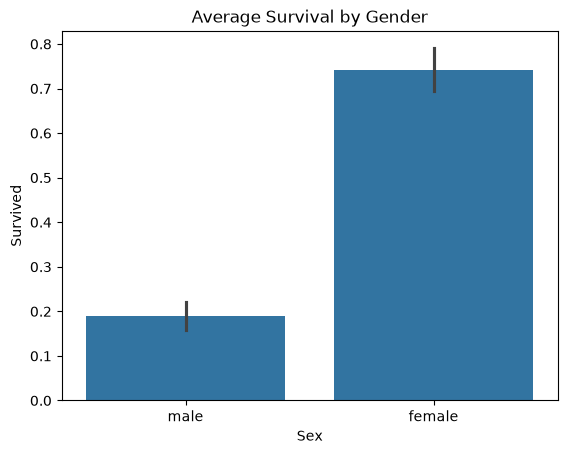

'Observation:\nThe average survival rate of females is higher than that of males.'

In [ ]:
#27. Average target value for each category

sns.barplot(data=df, x='Sex', y='Survived')
plt.title("Average Survival by Gender")
plt.show()

'''Observation:
The average survival rate of females is higher than that of males.'''

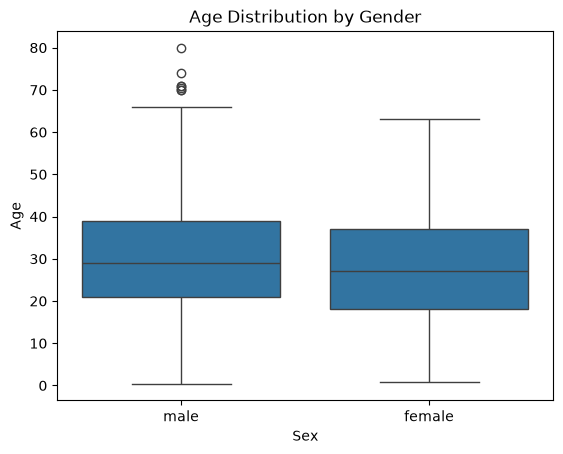

'Observation:\nThe box plots show the median, spread and potential outliers of age for males and females.'

In [ ]:
#28. Box plot of numerical vs categorical


sns.boxplot(data=df, x='Sex', y='Age')
plt.title("Age Distribution by Gender")
plt.show()

'''Observation:
The box plots show the median, spread and potential outliers of age for males and females.'''

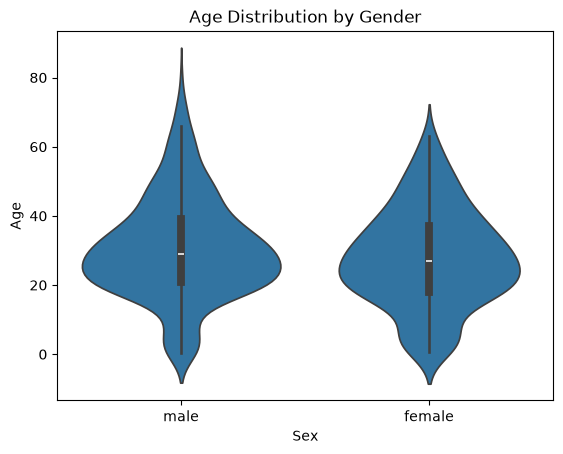

'Box plot vs Violin plot\nBox plot → median, quartiles and outliers clearly show karta hai.\nViolin plot → box plot ke saath distribution/density bhi show karta hai.'

In [ ]:
#29. Violin plot
sns.violinplot(data=df, x='Sex', y='Age')
plt.title("Age Distribution by Gender")
plt.show()

'''Box plot vs Violin plot
Box plot → median, quartiles and outliers clearly show karta hai.
Violin plot → box plot ke saath distribution/density bhi show karta hai.'''

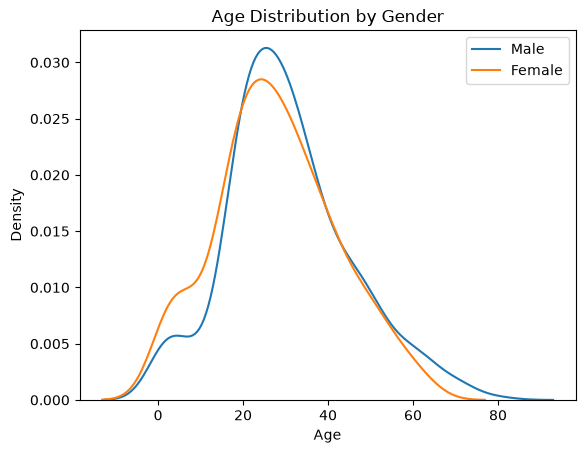

'Observation:\nThe KDE curves show how the age distributions of male and female passengers differ.'

In [ ]:
#30. KDE for different categories


sns.kdeplot(data=df[df['Sex'] == 'male'], x='Age', label='Male')
sns.kdeplot(data=df[df['Sex'] == 'female'], x='Age', label='Female')

plt.title("Age Distribution by Gender")
plt.legend()
plt.show()

'''Observation:
The KDE curves show how the age distributions of male and female passengers differ.'''

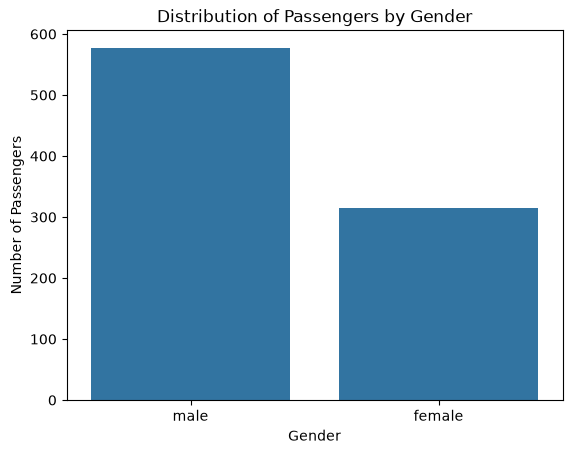

In [ ]:
#31. Count plot of a categorical feature


sns.countplot(data=df, x='Sex')

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.title("Distribution of Passengers by Gender")

plt.show()

Sex
male      577
female    314
Name: count, dtype: int64
Highest category: male
Number of observations: 577


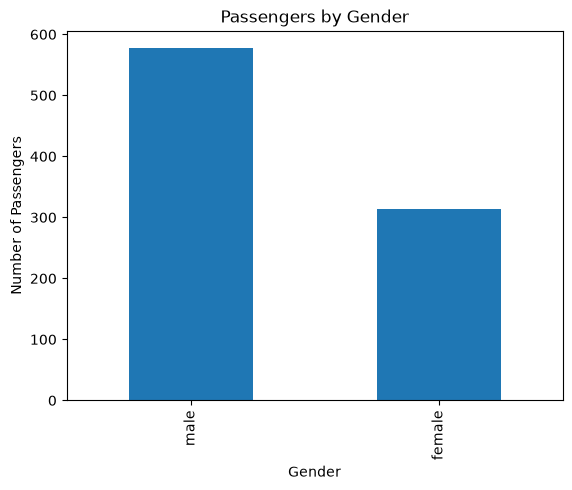

In [36]:
# 32. Category with highest observations

count = df['Sex'].value_counts()

print(count)

print("Highest category:", count.idxmax())
print("Number of observations:", count.max())

count.plot(kind='bar')

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.title("Passengers by Gender")

plt.show()

Sex
female    44.479818
male      25.523893
Name: Fare, dtype: float64


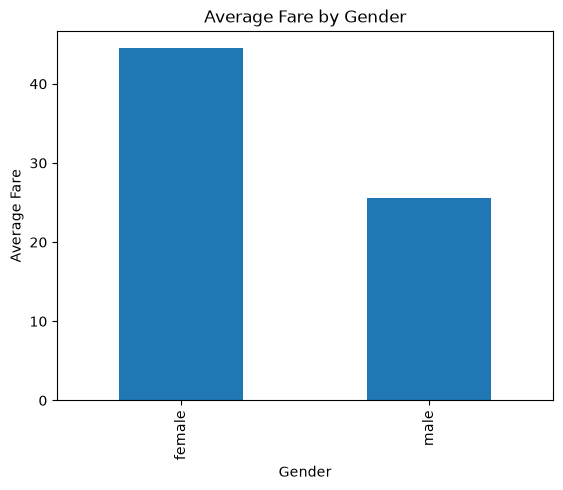

In [37]:
# 33. Average Fare for each gender

avg_fare = df.groupby('Sex')['Fare'].mean()

print(avg_fare)

avg_fare.plot(kind='bar')

plt.xlabel("Gender")
plt.ylabel("Average Fare")
plt.title("Average Fare by Gender")

plt.show()

In [38]:
# 34. Cross-tabulation

table = pd.crosstab(df['Sex'], df['Pclass'])

print(table)

Pclass    1    2    3
Sex                  
female   94   76  144
male    122  108  347


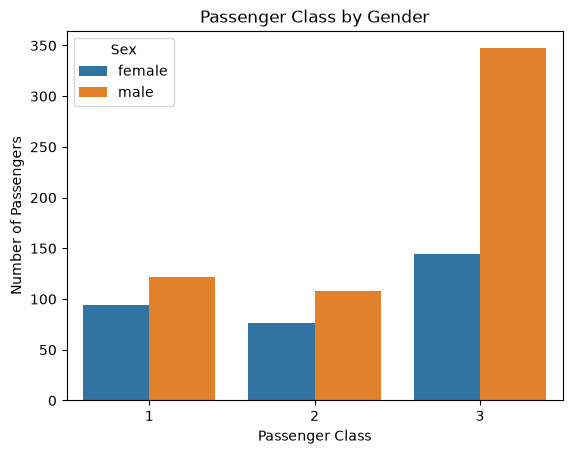

In [39]:
# 35. Grouped bar plot

sns.countplot(data=df, x='Pclass', hue='Sex')

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Passenger Class by Gender")

plt.show()

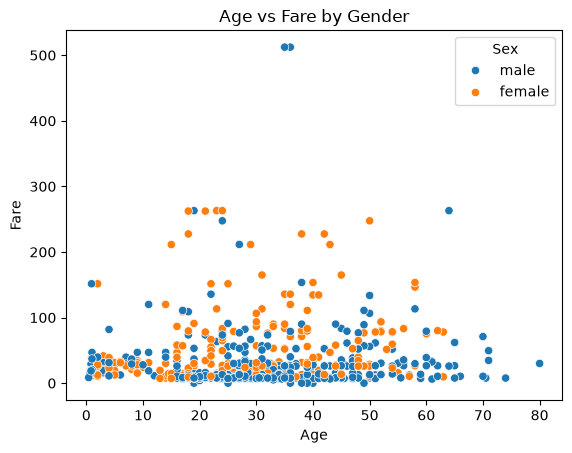

In [40]:
# 36. Scatter plot with category

sns.scatterplot(data=df, x='Age', y='Fare', hue='Sex')

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare by Gender")

plt.show()

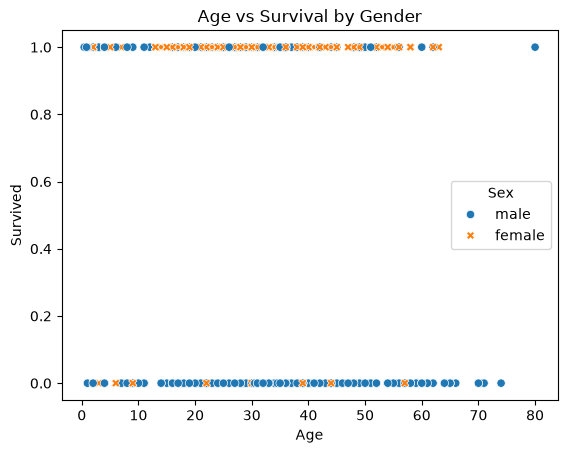

In [41]:
# 37. Age vs Survival by Gender

sns.scatterplot(
    data=df,
    x='Age',
    y='Survived',
    hue='Sex',
    style='Sex'
)

plt.xlabel("Age")
plt.ylabel("Survived")
plt.title("Age vs Survival by Gender")

plt.show()

PassengerId   -0.005007
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64
Most strongly correlated feature: Pclass
Correlation: -0.33848103596101514


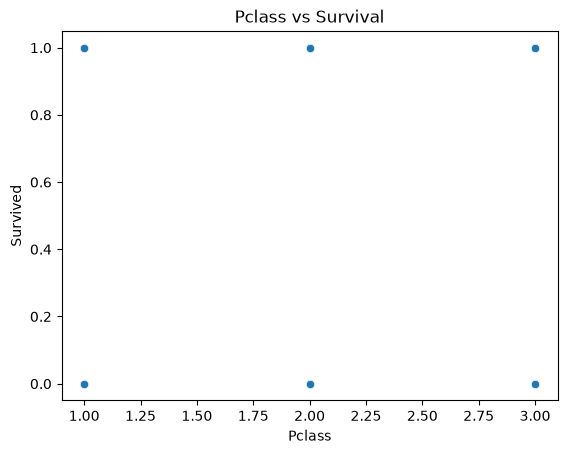

In [44]:
# 38. Feature most correlated with target

corr = df[numerical].corr()['Survived'].drop('Survived')

print(corr)

feature = corr.abs().idxmax()

print("Most strongly correlated feature:", feature)
print("Correlation:", corr[feature])

sns.scatterplot(data=df, x=feature, y='Survived')

plt.xlabel(feature)
plt.ylabel("Survived")
plt.title(feature + " vs Survival")

plt.show()

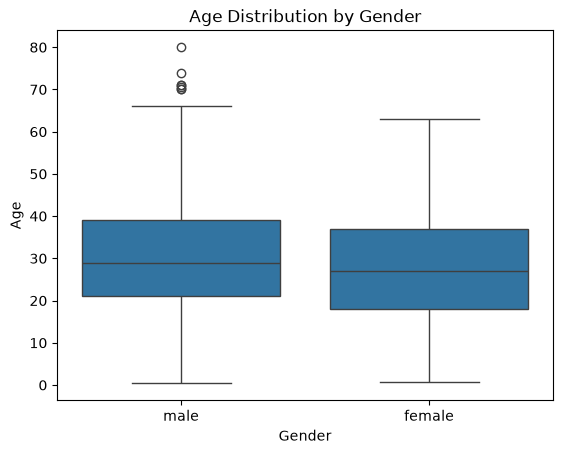

In [45]:
# 39. Box plot

sns.boxplot(data=df, x='Sex', y='Age')

plt.xlabel("Gender")
plt.ylabel("Age")
plt.title("Age Distribution by Gender")

plt.show()

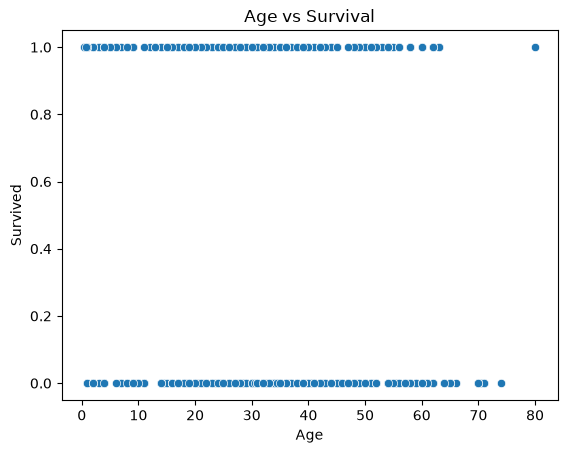

Correlation between Age and Survival: -0.07722109457217756


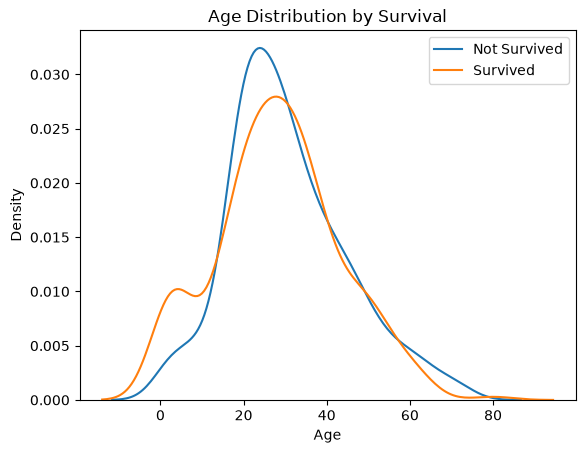

' Five observations\n\nThere is a weak relationship between Age and Survival.\nYounger passengers generally had a better chance of survival.\nThe correlation between Age and Survival is relatively low.\nThe box plot shows differences in age distributions between survivors and non-survivors.\nThe KDE plot shows that the age distributions of survivors and non-survivors are different, especially among younger passengers.'

In [47]:
# 40. Scatter plot

sns.scatterplot(data=df, x='Age', y='Survived')

plt.xlabel("Age")
plt.ylabel("Survived")
plt.title("Age vs Survival")

plt.show()

correlation = df['Age'].corr(df['Survived'])

print("Correlation between Age and Survival:", correlation)

sns.kdeplot(
    data=df[df['Survived'] == 0],
    x='Age',
    label='Not Survived'
)

sns.kdeplot(
    data=df[df['Survived'] == 1],
    x='Age',
    label='Survived'
)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Age Distribution by Survival")

plt.legend()
plt.show()

''' Five observations

There is a weak relationship between Age and Survival.
Younger passengers generally had a better chance of survival.
The correlation between Age and Survival is relatively low.
The box plot shows differences in age distributions between survivors and non-survivors.
The KDE plot shows that the age distributions of survivors and non-survivors are different, especially among younger passengers.'''